   MODELYEAR   MAKE       MODEL VEHICLECLASS  ENGINESIZE  CYLINDERS  \
0       2014  ACURA         ILX      COMPACT         2.0          4   
1       2014  ACURA         ILX      COMPACT         2.4          4   
2       2014  ACURA  ILX HYBRID      COMPACT         1.5          4   
3       2014  ACURA     MDX 4WD  SUV - SMALL         3.5          6   
4       2014  ACURA     RDX AWD  SUV - SMALL         3.5          6   

  TRANSMISSION FUELTYPE  FUELCONSUMPTION_CITY  FUELCONSUMPTION_HWY  \
0          AS5        Z                   9.9                  6.7   
1           M6        Z                  11.2                  7.7   
2          AV7        Z                   6.0                  5.8   
3          AS6        Z                  12.7                  9.1   
4          AS6        Z                  12.1                  8.7   

   FUELCONSUMPTION_COMB  FUELCONSUMPTION_COMB_MPG  CO2EMISSIONS  
0                   8.5                        33           196  
1                   

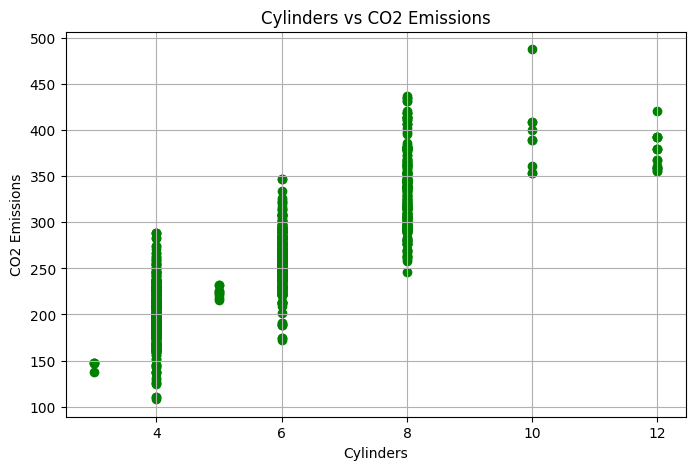

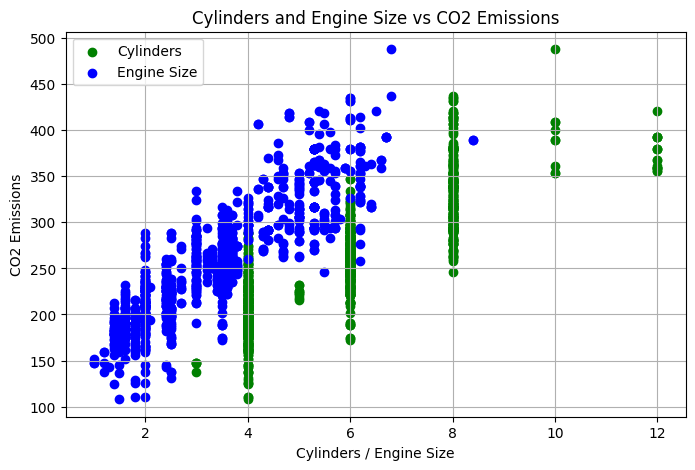

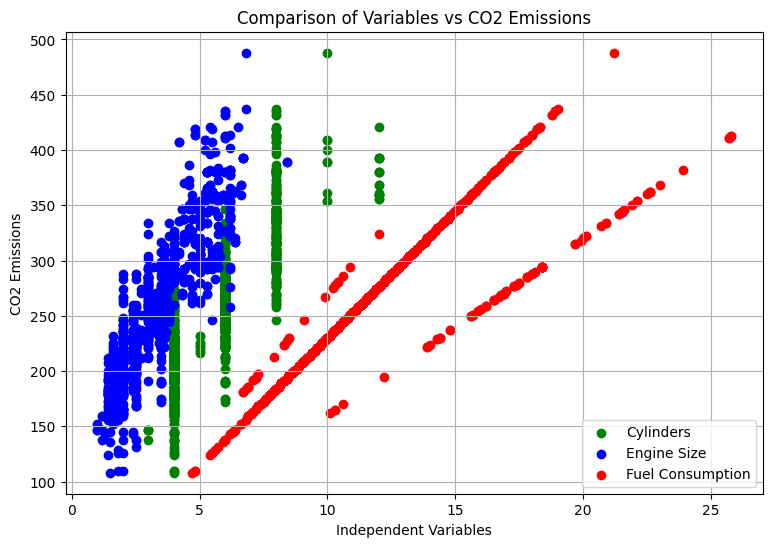


Q4: Cylinder vs CO2 Emissions
Coefficient: 29.47839878699531
Intercept: 86.08850036109291
Accuracy (R2): 0.7317140029783895

Q5: Fuel Consumption vs CO2 Emissions
Coefficient: 16.180900781199195
Intercept: 69.10302617988444
Accuracy (R2): 0.8071474868274242

Q6: Accuracy for Different Train-Test Ratios
   Test Size  Train Size  Cylinder Accuracy  Fuel Consumption Accuracy
0        0.1         0.9           0.727620                   0.788333
1        0.2         0.8           0.731714                   0.807147
2        0.3         0.7           0.741295                   0.800087
3        0.4         0.6           0.723917                   0.804410

Accuracy in Percentage
   Test Size  Train Size  Cylinder Accuracy (%)  Fuel Consumption Accuracy (%)
0        0.1         0.9              72.762024                      78.833316
1        0.2         0.8              73.171400                      80.714749
2        0.3         0.7              74.129498                      80.008723


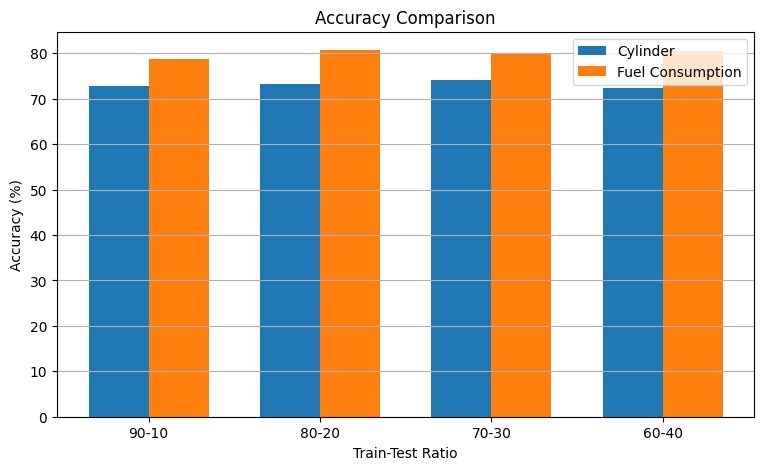

In [2]:
# Program Developed by: Nithishwar P
# Register Number: 212224060178

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv("/content/drive/MyDrive/FuelConsumption.csv")

print(df.head())
print(df.columns)


# Q1

plt.figure(figsize=(8, 5))

plt.scatter(
    df['CYLINDERS'],
    df['CO2EMISSIONS'],
    color='green'
)

plt.xlabel('Cylinders')
plt.ylabel('CO2 Emissions')
plt.title('Cylinders vs CO2 Emissions')
plt.grid(True)
plt.show()


# Q2

plt.figure(figsize=(8, 5))

plt.scatter(
    df['CYLINDERS'],
    df['CO2EMISSIONS'],
    color='green',
    label='Cylinders'
)

plt.scatter(
    df['ENGINESIZE'],
    df['CO2EMISSIONS'],
    color='blue',
    label='Engine Size'
)

plt.xlabel('Cylinders / Engine Size')
plt.ylabel('CO2 Emissions')
plt.title('Cylinders and Engine Size vs CO2 Emissions')
plt.legend()
plt.grid(True)
plt.show()


# Q3

plt.figure(figsize=(9, 6))

plt.scatter(
    df['CYLINDERS'],
    df['CO2EMISSIONS'],
    color='green',
    label='Cylinders'
)

plt.scatter(
    df['ENGINESIZE'],
    df['CO2EMISSIONS'],
    color='blue',
    label='Engine Size'
)

plt.scatter(
    df['FUELCONSUMPTION_COMB'],
    df['CO2EMISSIONS'],
    color='red',
    label='Fuel Consumption'
)

plt.xlabel('Independent Variables')
plt.ylabel('CO2 Emissions')
plt.title('Comparison of Variables vs CO2 Emissions')
plt.legend()
plt.grid(True)
plt.show()


# Q4

X = df[['CYLINDERS']]
y = df['CO2EMISSIONS']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model_cylinder = LinearRegression()

model_cylinder.fit(X_train, y_train)

y_pred = model_cylinder.predict(X_test)

accuracy_cylinder = r2_score(y_test, y_pred)

print("\nQ4: Cylinder vs CO2 Emissions")
print("Coefficient:", model_cylinder.coef_[0])
print("Intercept:", model_cylinder.intercept_)
print("Accuracy (R2):", accuracy_cylinder)


# Q5

X = df[['FUELCONSUMPTION_COMB']]
y = df['CO2EMISSIONS']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model_fuel = LinearRegression()

model_fuel.fit(X_train, y_train)

y_pred = model_fuel.predict(X_test)

accuracy_fuel = r2_score(y_test, y_pred)

print("\nQ5: Fuel Consumption vs CO2 Emissions")
print("Coefficient:", model_fuel.coef_[0])
print("Intercept:", model_fuel.intercept_)
print("Accuracy (R2):", accuracy_fuel)


# Q6

ratios = [0.1, 0.2, 0.3, 0.4]

cylinder_accuracy = []
fuel_accuracy = []

for ratio in ratios:

    X = df[['CYLINDERS']]
    y = df['CO2EMISSIONS']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=ratio,
        random_state=42
    )

    model = LinearRegression()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    cylinder_accuracy.append(
        r2_score(y_test, y_pred)
    )

    X = df[['FUELCONSUMPTION_COMB']]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=ratio,
        random_state=42
    )

    model = LinearRegression()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    fuel_accuracy.append(
        r2_score(y_test, y_pred)
    )


results = pd.DataFrame({
    'Test Size': ratios,
    'Train Size': [1 - r for r in ratios],
    'Cylinder Accuracy': cylinder_accuracy,
    'Fuel Consumption Accuracy': fuel_accuracy
})

print("\nQ6: Accuracy for Different Train-Test Ratios")

print(results)


results['Cylinder Accuracy (%)'] = (
    results['Cylinder Accuracy'] * 100
)

results['Fuel Consumption Accuracy (%)'] = (
    results['Fuel Consumption Accuracy'] * 100
)

print("\nAccuracy in Percentage")

print(
    results[
        [
            'Test Size',
            'Train Size',
            'Cylinder Accuracy (%)',
            'Fuel Consumption Accuracy (%)'
        ]
    ]
)


plt.figure(figsize=(9, 5))

x = np.arange(len(ratios))

width = 0.35

plt.bar(
    x - width / 2,
    results['Cylinder Accuracy (%)'],
    width,
    label='Cylinder'
)

plt.bar(
    x + width / 2,
    results['Fuel Consumption Accuracy (%)'],
    width,
    label='Fuel Consumption'
)

plt.xlabel('Train-Test Ratio')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison')

plt.xticks(
    x,
    ['90-10', '80-20', '70-30', '60-40']
)

plt.legend()
plt.grid(axis='y')

plt.show()